In [2]:
import h5py
from matplotlib.font_manager import findSystemFonts
from scipy.io import loadmat

def iterate_group(data: h5py.Group, final_data: dict):
    """
    Recursively iterate through a h5py Group and print its structure.
    """
    for key in data.keys():
        item = data[key]
        if isinstance(item, h5py.Group):
            final_data[key] = {}
            iterate_group(item, final_data[key])
        else:
            final_data[key] = item[:]
    return final_data

def load_data_matfile(path: str, name: list[str]=[]):
    with h5py.File(path, 'r') as f:
        # List all groups in the file
        # print("Keys in the file:", list(f.keys()))
        # Access the dataset
        
        if len(name) == 0:
            data = {}
            iterate_group(f, data)
            return data
        else:
            result = {}
            for key in name:
                if isinstance(f[key], h5py.Group):
                    # print("key is a group, iterating through it")
                    result[key] = iterate_group(f[key], {})
                else:
                    # print("key is a dataset, returning data")
                    data = f[key][:]
                    data = data.T  # Transpose to match MATLAB's column-major order
                    result[key] = data 
            return result

def load_result_matfile(path: str):
    data = loadmat(path)
    return data

In [3]:
BASE_PATH = "../result/round_{number}/"
CENTER_PATH = BASE_PATH + "{site}_Centers.mat"
TYP_PATH = BASE_PATH + "{site}_Typ.mat"

sample_path = CENTER_PATH.format(number=1, site='COBRE')

data = load_result_matfile(sample_path)

print("center keys: ", data.keys())

# print(data['Selected_Features'].T[0])
print(data['Center_SZ'].T[0])

typical_mat_file = TYP_PATH.format(number=1, site='COBRE')
typ_data = load_result_matfile(typical_mat_file)
print("typ keys: ", typ_data.keys())
print(typ_data['TypIDG1'].T[0])



center keys:  dict_keys(['__header__', '__version__', '__globals__', 'Selected_Features', 'Center_SZ', 'Center_HC'])
[0.14295927]
typ keys:  dict_keys(['__header__', '__version__', '__globals__', 'TypIDG1', 'TypIDG2'])
[  1   2   3   6   9  11  18  27  28  29  31  34  40  45  53  55  56  57
  59  60  62  64  65  68  74  76  77  78  79  81  82  83  86  98 100 101
 102 105 107 108 110 112 113 116 117 136 139 140 141 145 148 150 152 155
 156]


In [4]:
import os
from collections import Counter, defaultdict
import numpy as np

# ---------- Config ----------
BASE_DIR = "../result/round_{number}"        # root folder
ROUNDS = range(1, 6)            # i in 0..4
SITES = ['COBRE', 'FBIRN']
CENTER_FILE = '{site}_center_data.mat'
KEYS = ("typ_sz", "typ_hc")
KEYS_ALIAS = {
    'typ_sz': "TypIDG1",
    'typ_hc': "TypIDG2"
}
# ----------------------------

def count_values(arr) -> Counter:
    """
    Flatten array-like to 1-D and count values.
    Casts to Python scalars to make Counter happy.
    """
    if arr is None:
        return Counter()
    a = np.asarray(arr).ravel()
    # If the array is float but contains integers (e.g., 1.0, 2.0), you can
    # uncomment the next line to coerce to int:
    # a = a.astype(int)
    return Counter(map(lambda x: x.item() if hasattr(x, "item") else x, a))

# freq[site][key] -> Counter of values across all rounds
freq = {site: {k: Counter() for k in KEYS} for site in SITES}

"""
    {
        "COBRE": {
            Typ_SZ: {
                1: 2,
                2: 3,
            },
            Typ_HC: {
                4:2,
                3:2
            }
        }
    }
"""
feat_freq = {site: Counter() for site in SITES}

missing_files = []
missing_keys = defaultdict(lambda: defaultdict(int))  # missing_keys[site][key] count

for i in ROUNDS:
    for site in SITES:
        typical_path = os.path.join(BASE_PATH.format(number=i), site+'_Typ.mat')
        center_path = os.path.join(BASE_PATH.format(number=i), site+'_Centers.mat')
        
        center_data = load_result_matfile(center_path)
        typical_data = load_result_matfile(typical_path)
        
        
        ### finding the Subject ID's frequency:
        for k in KEYS:
            alias_name = KEYS_ALIAS[k]
            
            cnt = count_values(typical_data[alias_name].T[0])
            freq[site][k].update(cnt)
            
        ### finding the Selected features frequency:
        # print(center_data['Selected_Features'][0])
        feat_freq[site].update(center_data['Selected_Features'][0])

# ---------- Results ----------
# Pretty-print frequencies per site
for site in SITES:
    print(f"\n=== Site {site} ===")
    for k in KEYS:
        
        # print(f"  {k} (value -> count):")
        # for val, c in freq[site][k].most_common():
        #     print(f"    {val}: {c}")
    
        total = len(freq[site][k])
        num_keys_with_freq_k = sum(1 for val, count in freq[site][k].items() if count == 5)
        percentage_keys = (num_keys_with_freq_k / total * 100) if total > 0 else 0
        
        print(f"Site {site}, Key '{k}':")
        print(f"Total entries = {total}")
        print(f"Total subjects appeared constantly = {num_keys_with_freq_k}")
        print(f"Percentage = {percentage_keys:.2f}%")
    
    num_keys_with_freq_k = sum(1 for val, count in feat_freq[site].items() if count == 5)
    total_keys = len(feat_freq[site])
    percentage_keys = (num_keys_with_freq_k / total_keys * 100) if total_keys > 0 else 0

    print(f"\n[Selected Features] Site {site}:")
    print(f"  #features with frequency = {num_keys_with_freq_k}")
    print(f"  Percentage = {percentage_keys:.2f}%")


=== Site COBRE ===
Site COBRE, Key 'typ_sz':
Total entries = 55
Total subjects appeared constantly = 55
Percentage = 100.00%
Site COBRE, Key 'typ_hc':
Total entries = 48
Total subjects appeared constantly = 48
Percentage = 100.00%

[Selected Features] Site COBRE:
  #features with frequency = 209
  Percentage = 100.00%

=== Site FBIRN ===
Site FBIRN, Key 'typ_sz':
Total entries = 99
Total subjects appeared constantly = 99
Percentage = 100.00%
Site FBIRN, Key 'typ_hc':
Total entries = 92
Total subjects appeared constantly = 92
Percentage = 100.00%

[Selected Features] Site FBIRN:
  #features with frequency = 683
  Percentage = 100.00%


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import chi2
from scipy.constants import R

try:
    from sklearn.covariance import LedoitWolf
    _HAS_SK = True
except Exception:
    _HAS_SK = False

def plot_distance_boxplots(res, site_name="Site"):
    """res = output dict from distances_to_center_typicals(...)"""
    # Euclidean
    dE_HC = res["euclid"]["HC"]; dE_SZ = res["euclid"]["SZ"]
    fig, ax = plt.subplots(figsize=(6,4))
    ax.boxplot([dE_HC, dE_SZ], labels=["HC (typ)", "SZ (typ)"], showfliers=False)
    ax.set_title(f"{site_name} — Distance to class center (Euclidean)")
    ax.set_ylabel("Distance")
    ax.grid(True, axis="y", alpha=0.3)
    plt.show()

    # Mahalanobis (if present)
    dM_HC = res["mahal"]["HC"]; dM_SZ = res["mahal"]["SZ"]
    if dM_HC is not None and dM_SZ is not None:
        fig, ax = plt.subplots(figsize=(6,4))
        ax.boxplot([dM_HC, dM_SZ], labels=["HC (typ)", "SZ (typ)"], showfliers=False)
        ax.set_title(f"{site_name} — Distance to class center (Mahalanobis)")
        ax.set_ylabel("Distance")
        ax.grid(True, axis="y", alpha=0.3)
        plt.show()

def _ecdf(x):
    x = np.asarray(x)
    xs = np.sort(x)
    ys = np.arange(1, x.size + 1) / x.size
    return xs, ys

def plot_distance_ecdfs(res, site_name="Site"):
    """ECDFs for Euclidean (and Mahalanobis if available)."""
    # Euclidean
    dE_HC = res["euclid"]["HC"]; dE_SZ = res["euclid"]["SZ"]
    x1,y1 = _ecdf(dE_HC); x2,y2 = _ecdf(dE_SZ)
    fig, ax = plt.subplots(figsize=(6,4))
    ax.plot(x1, y1, label="HC (typ)")
    ax.plot(x2, y2, label="SZ (typ)")
    ax.set_title(f"{site_name} — ECDF of distance to center (Euclidean)")
    ax.set_xlabel("Distance"); ax.set_ylabel("F(x)")
    ax.grid(True, alpha=0.3); ax.legend()
    plt.show()

    # Mahalanobis (if present)
    dM_HC = res["mahal"]["HC"]; dM_SZ = res["mahal"]["SZ"]
    if dM_HC is not None and dM_SZ is not None:
        x1,y1 = _ecdf(dM_HC); x2,y2 = _ecdf(dM_SZ)
        fig, ax = plt.subplots(figsize=(6,4))
        ax.plot(x1, y1, label="HC (typ)")
        ax.plot(x2, y2, label="SZ (typ)")
        ax.set_title(f"{site_name} — ECDF of distance to center (Mahalanobis)")
        ax.set_xlabel("Distance"); ax.set_ylabel("F(x)")
        ax.grid(True, alpha=0.3); ax.legend()
        plt.show()

def plot_pca_ellipses_typicals(
    X,                 # (N, F) full features (no labels)
    feat_idx,          # indices of Bonferroni-selected features used to build center_data
    typ_idx_HC,        # indices (or boolean mask) of typical HC in THIS site
    typ_idx_SZ,        # indices (or boolean mask) of typical SZ in THIS site
    center_HC=None,    # (F_sel,) optional: center vector for HC (to plot as star)
    center_SZ=None,    # (F_sel,) optional: center vector for SZ (to plot as star)
    site_name="Site"
):
    def _to_mask_ellipses(n, idx_or_mask):
        arr = np.asarray(idx_or_mask)
        if arr.dtype == bool:
            return arr
        mask = np.zeros(n, dtype=bool); mask[arr.astype(int)] = True; return mask

    # 1) restrict to selected feature subspace
    Fsel = np.asarray(feat_idx, dtype=int)
    Xsel = X[:, Fsel]
    mask_HC = _to_mask_ellipses(X.shape[0], typ_idx_HC)
    mask_SZ = _to_mask_ellipses(X.shape[0], typ_idx_SZ)
    
    X_HC = Xsel[mask_HC]
    X_SZ = Xsel[mask_SZ]

    # 2) PCA on typicals (both classes together), to 2D
    X_typ = np.vstack([X_HC, X_SZ])
    pca = PCA(n_components=2, random_state=42).fit(X_typ)
    Z_HC = pca.transform(X_HC)
    Z_SZ = pca.transform(X_SZ)

    # 3) 95% covariance ellipses
    def ellipse_params(Z2):
        mu = Z2.mean(axis=0)
        C = np.cov(Z2, rowvar=False)
        vals, vecs = np.linalg.eigh(C); order = np.argsort(vals)[::-1]
        vals, vecs = vals[order], vecs[:, order]
        r = np.sqrt(vals * chi2.ppf(0.95, df=2))   # radii along eigenvectors
        theta = np.degrees(np.arctan2(vecs[1,0], vecs[0,0]))
        area = float(np.pi * r[0] * r[1])         # ellipse area
        return mu, r, theta, area

    mu_HC, r_HC, th_HC, area_HC = ellipse_params(Z_HC)
    mu_SZ, r_SZ, th_SZ, area_SZ = ellipse_params(Z_SZ)

    # 4) plot
    fig, ax = plt.subplots(figsize=(6,5))
    ax.scatter(Z_HC[:,0], Z_HC[:,1], s=18, alpha=0.55, label="HC (typ)")
    ax.scatter(Z_SZ[:,0], Z_SZ[:,1], s=18, alpha=0.55, label="SZ (typ)")

    def draw_ellipse(mu, r, theta, **kw):
        t = np.linspace(0, 2*np.pi, 400)
        R = np.array([[np.cos(np.radians(theta)), -np.sin(np.radians(theta))],
                      [np.sin(np.radians(theta)),  np.cos(np.radians(theta))]])
        pts = (R @ np.vstack([r[0]*np.cos(t), r[1]*np.sin(t)])).T + mu
        ax.plot(pts[:,0], pts[:,1], **kw)

    draw_ellipse(mu_HC, r_HC, th_HC, lw=2, label="HC 95% ellipse")
    draw_ellipse(mu_SZ, r_SZ, th_SZ, lw=2, label="SZ 95% ellipse")

    # (optional) project and plot center_data as stars
    if center_HC is not None and center_SZ is not None:
        Cstar_HC = pca.transform(center_HC.reshape(1,-1))
        Cstar_SZ = pca.transform(center_SZ.reshape(1,-1))
        ax.scatter(Cstar_HC[0,0], Cstar_HC[0,1], marker="*", s=160, edgecolor="k", zorder=5, label="HC center")
        ax.scatter(Cstar_SZ[0,0], Cstar_SZ[0,1], marker="*", s=160, edgecolor="k", zorder=5, label="SZ center")

    var2 = pca.explained_variance_ratio_[:2].sum() * 100
    ax.set_title(f"{site_name} — PCA (2D) of typicals with 95% ellipses (var≈{var2:.1f}%)")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(loc="best"); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    return {"HC_ellipse_area": area_HC, "SZ_ellipse_area": area_SZ, "pca_var_2d_pct": float(var2)}


def _to_mask(n, idx_or_mask):
    print("inside Mask: ", n, len(idx_or_mask))
    arr = np.asarray(idx_or_mask)
    print("lenght of arr: ", len(arr))
    if arr.dtype == bool:
        assert arr.size == n, "Boolean mask length must match n_samples."
        return arr
    mask = np.zeros(n, dtype=bool)
    mask[arr.astype(int)] = True
    return mask

def convert_to_zero_ind(arr: np.array):
    
    out = arr.astype(int)
    out = out-1
    
    return out

def distances_to_center_typicals(
    X,                    # (N, F) raw features for a site
    y,                    # (N,) labels (unused here; kept for sanity if you need)
    feat_idx,             # (F_sel,) feature indices used to build centers
    center_HC,            # (F_sel,) HC center (mean over typical HCs on feat_idx)
    center_SZ,            # (F_sel,) SZ center (mean over typical SZs on feat_idx)
    typ_idx_HC,           # indices OR boolean mask of typical HC subjects in this site
    typ_idx_SZ,           # indices OR boolean mask of typical SZ subjects in this site
    use_mahalanobis=True  # optional extra diagnostic (not in MATLAB)
):
    """
    Computes distances of *typical* subjects to their own class center
    in the exact subspace the centers were built in (no extra scaling).

    Returns:
      {
        "euclid": {"HC": dE_HC (n_HC,), "SZ": dE_SZ (n_SZ,)},
        "mahal":  {"HC": dM_HC (n_HC,) or None, "SZ": dM_SZ (n_SZ,) or None},
        "summary": { medians/IQRs for quick logging }
      }
    """
    X = np.asarray(X)
    Fsel = np.asarray(feat_idx, dtype=int)
    mask_HC = _to_mask(X.shape[0], typ_idx_HC)
    mask_SZ = _to_mask(X.shape[0], typ_idx_SZ)

    # Project to the exact feature subset used for centers
    X_HC = X[mask_HC][:, Fsel]
    X_SZ = X[mask_SZ][:, Fsel]

    # --- Euclidean (MATLAB-parity) ---
    dE_HC = np.linalg.norm(X_HC - center_HC, axis=1)
    dE_SZ = np.linalg.norm(X_SZ - center_SZ, axis=1)

    # --- Mahalanobis (optional diagnostic) ---
    dM_HC = dM_SZ = None
    if use_mahalanobis and _HAS_SK:
        def mahal(Xg, Cg):
            # Ledoit–Wolf shrinkage keeps Σ^{-1} stable when F_sel is large
            if Xg.shape[0] < 3:
                return np.linalg.norm(Xg - Cg, axis=1)  # fallback
            lw = LedoitWolf().fit(Xg)  # covariance from the same group/subspace
            P = lw.precision_
            Xm = Xg - Cg
            d2 = np.einsum('ij,jk,ik->i', Xm, P, Xm)
            d2[d2 < 0] = 0
            return np.sqrt(d2)
        dM_HC = mahal(X_HC, center_HC)
        dM_SZ = mahal(X_SZ, center_SZ)

    # Quick summary stats
    def _iqr(x):
        q1, q3 = np.percentile(x, [25, 75])
        return float(np.median(x)), float(q3 - q1)

    summary = {
        "euclid": {
            "HC_median": _iqr(dE_HC)[0], "HC_IQR": _iqr(dE_HC)[1],
            "SZ_median": _iqr(dE_SZ)[0], "SZ_IQR": _iqr(dE_SZ)[1],
        },
        "mahal": None
    }
    if dM_HC is not None and dM_SZ is not None:
        summary["mahal"] = {
            "HC_median": _iqr(dM_HC)[0], "HC_IQR": _iqr(dM_HC)[1],
            "SZ_median": _iqr(dM_SZ)[0], "SZ_IQR": _iqr(dM_SZ)[1],
        }

    return {
        "euclid": {"HC": dE_HC, "SZ": dE_SZ},
        "mahal":  {"HC": dM_HC, "SZ": dM_SZ},
        "summary": summary
    }


In [9]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

def _to_mask(n, idx_or_mask):
    arr = np.asarray(idx_or_mask).ravel()
    if arr.dtype == bool:
        assert arr.size == n, f"Mask length {arr.size} != n={n}"
        return arr
    idx = arr.astype(int)
    if idx.size and idx.min() >= 1:
        idx = idx - 1  # MATLAB → Python
    if idx.size and (idx.min() < 0 or idx.max() >= n):
        raise IndexError(f"indices out of bounds for n={n}")
    m = np.zeros(n, dtype=bool); m[idx] = True
    return m

def pairwise_heatmap_typicals(
    X,               # (N, F) features
    feat_idx,        # selected feature indices used for centers
    typ_idx_HC,      # indices or boolean mask for typical HC
    typ_idx_SZ,      # indices or boolean mask for typical SZ
    metric="euclidean"
):
    """Return full pairwise distance matrix (HC first, then SZ) and block means."""
    Fsel = np.asarray(feat_idx).ravel().astype(int)
    if Fsel.size and Fsel.min() >= 1:
        Fsel = Fsel - 1  # MATLAB → Python

    mHC = _to_mask(X.shape[0], typ_idx_HC)
    mSZ = _to_mask(X.shape[0], typ_idx_SZ)

    X_HC = X[mHC][:, Fsel]
    X_SZ = X[mSZ][:, Fsel]

    X_stacked = np.vstack([X_HC, X_SZ])                   # order: [HC ... ; SZ ...]
    D = squareform(pdist(X_stacked, metric=metric))        # (n_typ, n_typ)
    n_hc, n_sz = X_HC.shape[0], X_SZ.shape[0]

    # Block means (excluding diagonals for within-class blocks)
    def upper_mean(A):
        if A.size == 0: return np.nan
        iu = np.triu_indices_from(A, k=1)
        return float(A[iu].mean()) if iu[0].size else np.nan

    D_HC = D[:n_hc, :n_hc]
    D_SZ = D[n_hc:, n_hc:]
    D_BET = D[:n_hc, n_hc:]

    block_means = {
        "within_HC": upper_mean(D_HC),
        "within_SZ": upper_mean(D_SZ),
        "between":   float(D_BET.mean()) if D_BET.size else np.nan,
        "counts": {"HC": int(n_hc), "SZ": int(n_sz)}
    }
    return D, n_hc, block_means

def plot_pairwise_heatmap(D, n_hc, site_name="Site"):
    """Visual HC↔SZ block structure; HC rows/cols are first n_hc."""
    fig, ax = plt.subplots(figsize=(6,6))
    im = ax.imshow(D, interpolation="nearest", aspect="equal")
    ax.axhline(n_hc-0.5, color="w", lw=1.5)
    ax.axvline(n_hc-0.5, color="w", lw=1.5)
    ax.set_title(f"{site_name} — Pairwise distances among typicals")
    ax.set_xlabel("Subjects (HC first, then SZ)"); ax.set_ylabel("Subjects")
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Distance")
    plt.tight_layout(); plt.show()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def _infer_labels(df: pd.DataFrame, label_col: str | None):
    """Return (y_true: {0=HC,1=SZ}, colname_used)."""
    if label_col is None:
        # Try common names
        for c in ["label", "y", "class", "Group", "Diagnosis"]:
            if c in df.columns:
                label_col = c
                break
        if label_col is None:
            raise ValueError("Please provide label_col (e.g., 'label').")
    raw = df[label_col].to_numpy()

    # Map to 0/1 with 0=HC, 1=SZ
    if raw.dtype.kind in "iu":  # ints
        u = set(np.unique(raw).tolist())
        if u == {0, 1}:
            y = raw.astype(int)  # assume 1=SZ
        elif u == {1, 2}:
            # Matches your MATLAB convention: 1=SZ, 2=HC
            y = (raw == 1).astype(int)
        else:
            raise ValueError(f"Unhandled integer label set: {u}")
    else:
        # strings like "HC"/"SZ" (case-insensitive)
        s = np.char.upper(raw.astype(str))
        y = (s == "SZ").astype(int)
    return y, label_col



def evaluate_and_plot_score_classifier(
    df: pd.DataFrame,
    *,
    score_col: str | None = None,   # default: last column
    label_col: str | None = None,   # try to infer if None
    outdir: str | None = None,      # folder to save figs (optional)
    site_name: str = "Site",
    show: bool = True
):
    plt.figure(figsize=(7,4))
    sns.stripplot(
        data=df, 
        x="average", y=site_name, 
        jitter=True, 
        orient="h", 
        size=4
    )

    # Add vertical line at threshold = 0
    plt.axvline(0, color="tab:blue", linestyle="--", label="threshold = 0")

    # Customize y-axis (class labels)
    plt.yticks([0, 1], ["HC (true)", "SZ (true)"])

    # Customize x-axis labels on both sides
    plt.xlabel("Comprehensive score")
    plt.title(f"{site_name} — Scores by class (strip plot)")
    plt.legend()

    plt.show()

final sz:  40
final hc:  117


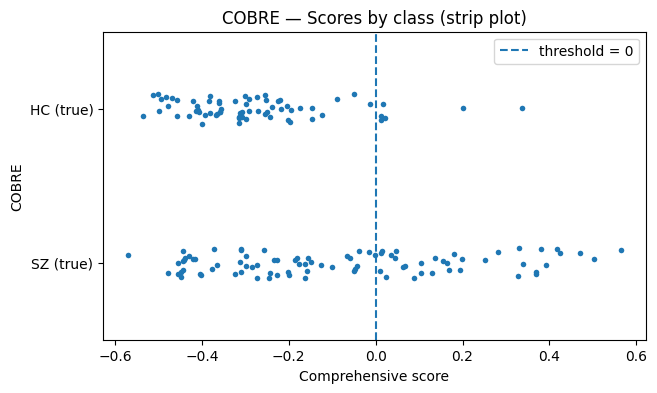

final sz:  163
final hc:  148


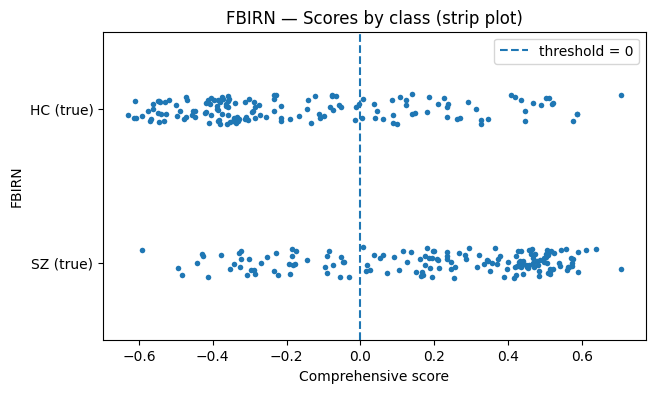

final sz:  40
final hc:  117


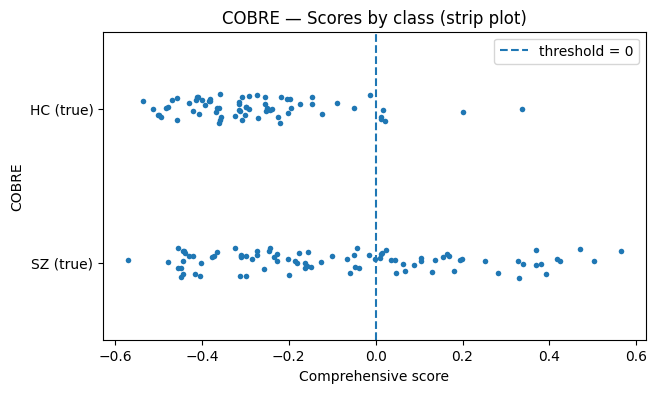

final sz:  163
final hc:  148


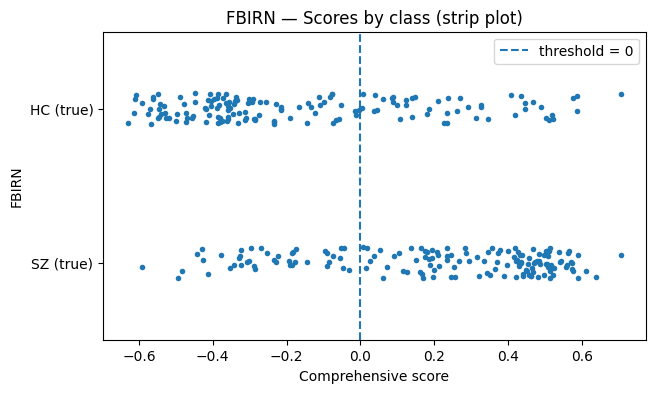

final sz:  40
final hc:  117


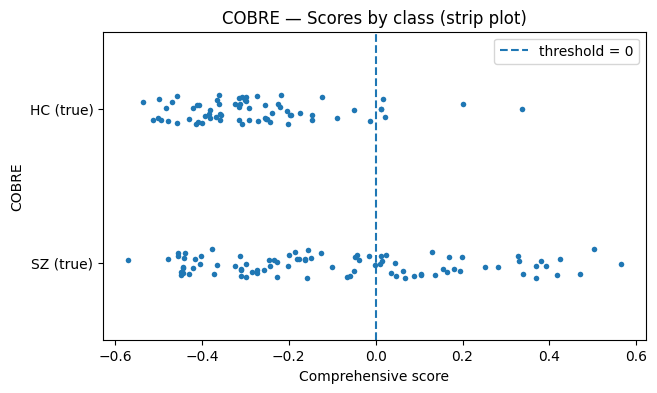

final sz:  163
final hc:  148


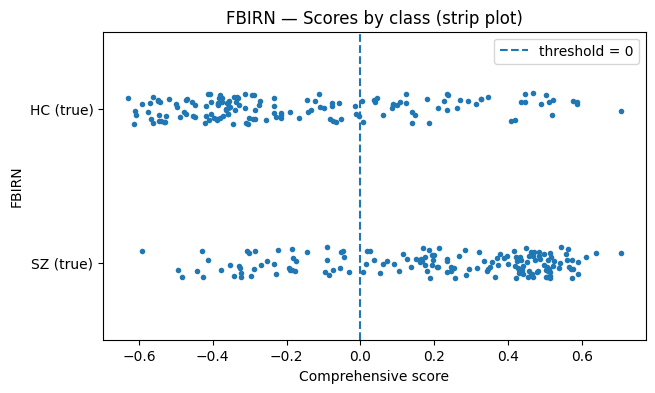

final sz:  40
final hc:  117


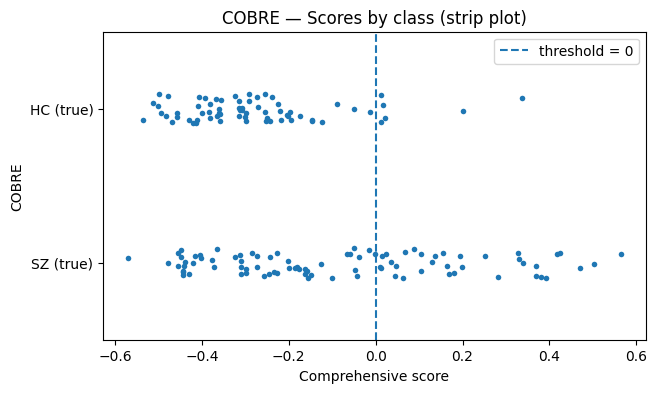

final sz:  163
final hc:  148


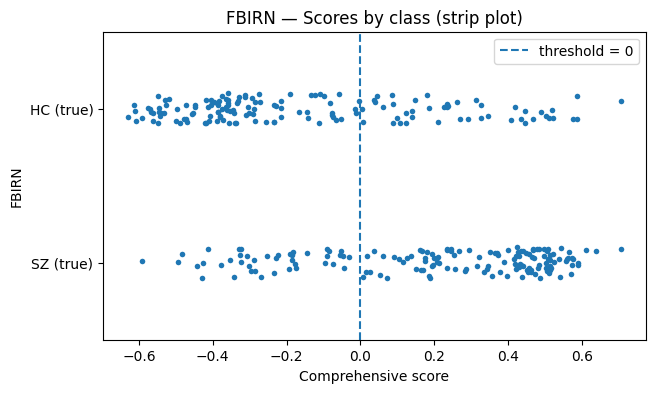

final sz:  40
final hc:  117


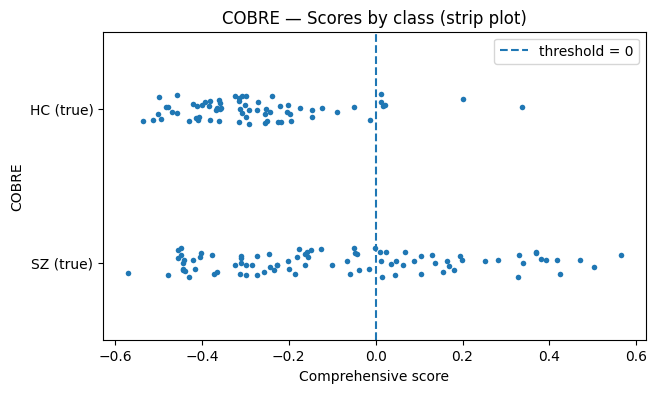

final sz:  163
final hc:  148


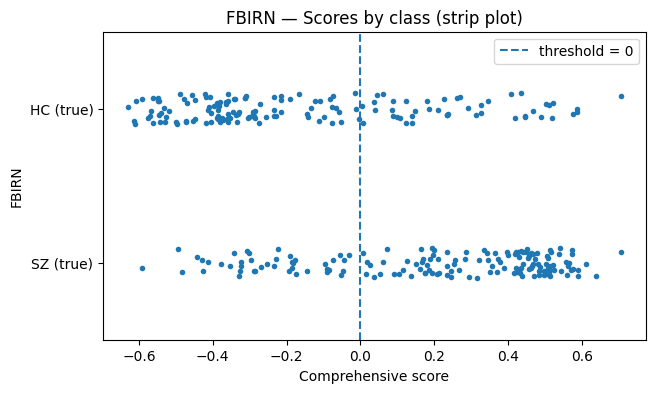

In [11]:

for i in ROUNDS:
    for site in SITES:
        
        typical_path = os.path.join(BASE_PATH.format(number=i), site+'_Typ.mat')
        center_path = os.path.join(BASE_PATH.format(number=i), site+'_Centers.mat')
        score_path = os.path.join(BASE_PATH.format(number=i), site+'_Score.mat')
        
        center_data = load_result_matfile(center_path)
        typical_data = load_result_matfile(typical_path)
        score_data = load_result_matfile(score_path)['IndepScore'][:]
        
        
        score_df = pd.DataFrame(columns=[site, "average"])
        for i in range(score_data.shape[1]):
            if len(np.unique(score_data[:, i])) == 2:
                score_df[site] = score_data[:, i]
        
        score_df["average"] = score_data[:, -1]
        
        final_sz_count = (score_df["average"] > 0).sum()
        final_hc_count = len(score_df) - final_sz_count
        
        print("final sz: ", final_sz_count)
        print("final hc: ", final_hc_count)
        
        data_path = os.path.join('../data', site+'.mat')
        data = load_data_matfile(data_path)[site].T
        
        labels = data[:,-1]
        data = data[:, :-1]
        
        # print(data)

        selected_features = convert_to_zero_ind(np.asarray(center_data['Selected_Features']).ravel())
        typical_sz_ind = convert_to_zero_ind(np.asarray(typical_data['TypIDG1']).ravel())
        typical_hc_ind = convert_to_zero_ind(np.asarray(typical_data['TypIDG2']).ravel())
        
        center_hc = np.asarray(center_data['Center_HC']).ravel()
        center_sz = np.asarray(center_data['Center_SZ']).ravel()
        # print("center hc: ", center_hc)
        # print("center_sz: ", center_sz)

        # print(data.shape)
        # print("labels: ", len(labels))
        # print("selected_features: ", len(selected_features))
        # print("center_hc: ", len(center_hc))
        # print("center_sz: ", len(center_sz))
        # print("typical_hc_ind: ", len(typical_hc_ind))
        # print("typical_sz_ind: ", len(typical_sz_ind))
        
        # ans = distances_to_center_typicals (
        #     data, labels,
        #     selected_features, center_hc, center_sz, typical_hc_ind, typical_sz_ind
        # )
        
        # plot_distance_boxplots(ans, site_name=f"Site {site}")
        # plot_distance_ecdfs(ans, site_name=f"Site {site}")
        
        # plot_pca_ellipses_typicals(
        #     data, selected_features,
        #     typical_hc_ind, typical_sz_ind, center_hc, center_sz, site
        # )

        # D, n_hc, stats = pairwise_heatmap_typicals(
        #     X=data,
        #     feat_idx=selected_features,
        #     typ_idx_HC=typical_hc_ind,
        #     typ_idx_SZ=typical_sz_ind,
        #     metric="euclidean"
        # )
        # print(stats)               # {'within_HC': ..., 'within_SZ': ..., 'between': ..., 'counts': {...}}
        # plot_pairwise_heatmap(D, n_hc, site_name=site)
        
        evaluate_and_plot_score_classifier(
            score_df,
            score_col=None,        # last column by default
            label_col=site,     # or None to let it infer
            outdir=os.path.join(BASE_DIR.format(number=i)),
            site_name=site,
            show=True
        )
